# Configurações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
home = os.getcwd()
diretorio_projeto = home
os.chdir(diretorio_projeto)

if diretorio_projeto not in sys.path:
    sys.path.append(diretorio_projeto)

from visualisation import plotar_metricas_cv, plotar_loss_cv, imprimir_metricas_finais


In [3]:

def compilar_estatisticas_cv(caminho_raiz, nome_logger="cv_resultados", num_folds=10):
    lista_dfs = []

    for i in range(1, num_folds + 1):
        caminho_csv = f"{caminho_raiz}/{nome_logger}/fold_{i}/metrics.csv"

        if os.path.exists(caminho_csv):
            df_fold = pd.read_csv(caminho_csv)
            df_fold_limpo = df_fold.groupby('epoch').mean().reset_index()
            lista_dfs.append(df_fold_limpo)
        else:
            print(f"Aviso: Log do fold_{i} não encontrado.")

    if not lista_dfs:
        raise ValueError("Nenhum arquivo de log encontrado.")

    df_completo = pd.concat(lista_dfs)

    df_stats = df_completo.groupby('epoch').agg(['mean', 'std'])
    df_stats.columns = ['_'.join(col).strip() for col in df_stats.columns.values]
    df_stats = df_stats.reset_index()

    return df_stats


In [4]:

diretorio_logs = f"{diretorio_projeto}/logs"

# Análise do modelo

# Resultados



## Baseline


In [ ]:
df_resultados= compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados")

In [ ]:
print("Resultados do modelo baseline:")
imprimir_metricas_finais(df_resultados)
plotar_metricas_cv(df_resultados)

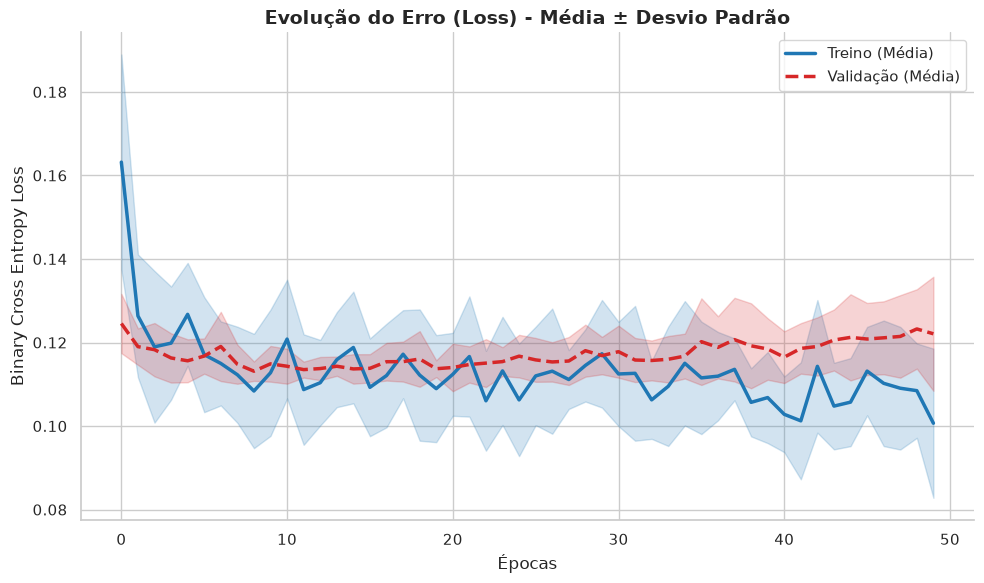

In [9]:
plotar_loss_cv(df_resultados)

Essas mudanças abruptas e loss alta podem indicar que nossa learning rate está muito alta, alem disso podemos ver que a partir da epoca 27 o modelo começa a sofrer um overfitting, com a loss do treino descendo enquanto a loss de validação aumenta.

Alem disso, para a v2 vamos adicionar class weighting para tentar melhorar o f1 score.

## modelo V2

In [ ]:
df_resultados_v2 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v2")

In [ ]:
print("\nResultados do modelo v2:")
imprimir_metricas_finais(df_resultados_v2)
plotar_metricas_cv(df_resultados_v2)

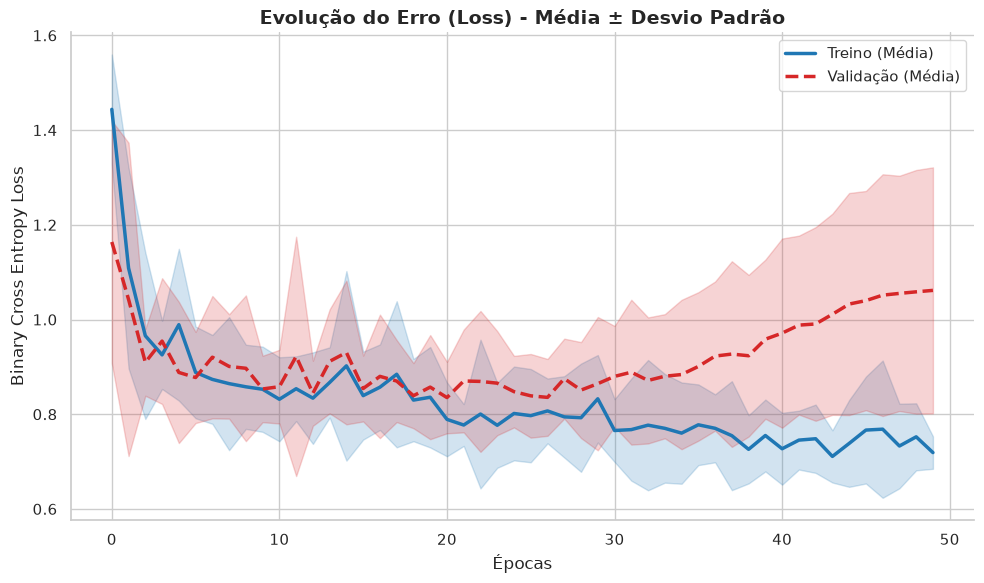

In [10]:
plotar_loss_cv(df_resultados_v2)